## Hypothesis: Momentum-first signal with sentiment as a **modifier** (continuation)

**Origin** — Follows **`04-hyp_neg_sent_momentum.ipynb`**. That notebook found a **partially supported** interaction: extreme negative sentiment (bottom 10% of scores among **negative-labeled** MAG7 articles) **changes** the slope linking prior-day **momentum** to **next-day** return and to downside probability, while the extreme **level** effect alone is weak. Temporal and definition robustness were **mixed**.

**This notebook** implements the **Next Steps** from 04: tighter inference (clustering), clearer nonlinear summaries (logit marginal effects), and **time-aware validation** (walk-forward or rolling estimation), so a **momentum-primary + sentiment-modifier** spec is stress-tested before any implementation narrative.

## Research questions

1. Under **cluster-robust** standard errors (e.g. by `price_date` and/or `ticker`), does the **momentum × extreme** interaction remain informative?
2. For the downside **logit**, what are **average marginal effects** of momentum, extreme flag, and interaction (not just logit coefficients)?
3. Does a simple **walk-forward** (train on past, score/evaluate on future) or **rolling** refit show **out-of-sample** patterns consistent with the in-sample interaction story?
4. **Sensitivity:** shorter recent windows (e.g. 2026-only), alternative extreme rules—do conclusions flip?

## Assumptions (inherit from 04)

- **Window**: `WINDOW_START`–`WINDOW_END` from `msa.utils.vars`.
- **Universe**: MAG7; `sentiment_label == "negative"` for the modifier analysis (same starting point as 04; extensions to other labels are optional later).
- **Outcomes / features**: `forward_return_1d`, `momentum_1d`, `neg_extreme`, `momentum_x_extreme` built as in 04 (`prepare_analysis_frame`, `q_bottom=0.10` by default).


## Data loading (minimal)

Same joined table as 04: `get_joined_dataset()` → `gdelt_ohlcv_join.csv`.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from msa.utils.paths import get_joined_dataset
from msa.utils.vars import MAG7_TICKERS, WINDOW_END, WINDOW_START

INPUT_PATH = get_joined_dataset()
df = pd.read_csv(
    INPUT_PATH,
    parse_dates=["date", "article_date", "price_date"],
)

print(f"Loaded {len(df):,} rows from {INPUT_PATH.name}")
df.head()


Loaded 89,405 rows from gdelt_ohlcv_join.csv


,seendate,url,title,language,domain,socialimage,company,ticker,date,sentiment_score,sentiment_confidence,sentiment_label,article_date,price_date,next_open,next_high,next_low,next_close,next_adj_close,next_volume
0,2024-02-08 00:00:00+00:00,https://www.businesstimes.com.sg/companies-mar...,Arm soars after expansion into new markets buo...,English,businesstimes.com.sg,https://static1.businesstimes.com.sg/s3fs-publ...,Apple,AAPL,2024-02-08,0.815164,0.877368,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
1,2024-02-08 00:45:00+00:00,https://www.hucknalldispatch.co.uk/lifestyle/f...,Dutch Barn Orchard Vodka achieves nationwide l...,English,hucknalldispatch.co.uk,https://www.hucknalldispatch.co.uk/webimg/b25l...,Apple,AAPL,2024-02-08,0.927444,0.938555,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
2,2024-02-08 00:45:00+00:00,https://www.fool.com/earnings/call-transcripts...,PayPal ( PYPL ) Q4 2023 Earnings Call Transcript,English,fool.com,NaN,Apple,AAPL,2024-02-08,-0.010950,0.934771,neutral,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
3,2024-02-08 01:15:00+00:00,https://invezz.com/news/2024/02/07/disney-q1-e...,Disney Q1 earnings : dividend increased as DTC...,English,invezz.com,https://invezz.com/wp-content/uploads/2022/11/...,Apple,AAPL,2024-02-08,0.838071,0.908904,positive,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
4,2024-02-08 01:15:00+00:00,https://www.nbcnewyork.com/news/business/money...,"Jim Cramer says recent moves in Apple , Chipot...",English,nbcnewyork.com,https://media.nbcnewyork.com/2023/11/107113454...,Apple,AAPL,2024-02-08,-0.320946,0.543592,neutral,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200


## Filtering & daily panel (same as 04)


In [2]:
print("=" * 70)
print("DATA FILTERING PIPELINE")
print("=" * 70)

print(f"\n1. Initial dataset: {len(df):,} rows")

df_filtered = df[
    (df["price_date"].dt.normalize() >= pd.Timestamp(WINDOW_START))
    & (df["price_date"].dt.normalize() <= pd.Timestamp(WINDOW_END))
].copy()
print(f"2. After date window ({WINDOW_START} to {WINDOW_END}): {len(df_filtered):,} rows")

df_mag7 = df_filtered[df_filtered["ticker"].isin(MAG7_TICKERS)].copy()
print(f"3. After MAG7 filter: {len(df_mag7):,} rows")

df_mag7_neg = df_mag7[df_mag7["sentiment_label"] == "negative"].copy()
print(f"4. Negative-sentiment rows: {len(df_mag7_neg):,}")

print("\n" + "=" * 70)


DATA FILTERING PIPELINE

1. Initial dataset: 89,405 rows
2. After date window (2024-02-23 to 2026-02-23): 88,851 rows
3. After MAG7 filter: 88,851 rows
4. Negative-sentiment rows: 11,145



In [3]:
# Daily panel + merge to negative article rows (see 04 for definitions)
returns_daily = (
    df_mag7.groupby(["price_date", "ticker"], as_index=False).agg(close=("next_close", "first"))
)
returns_daily["price_date"] = pd.to_datetime(returns_daily["price_date"]).dt.normalize()
returns_daily = returns_daily.sort_values(["ticker", "price_date"]).reset_index(drop=True)
returns_daily["return_1d"] = returns_daily.groupby("ticker")["close"].pct_change()
returns_daily["forward_return_1d"] = returns_daily.groupby("ticker")["return_1d"].shift(-1)

_mom = returns_daily[["price_date", "ticker", "return_1d"]].copy()
_mom["momentum_1d"] = _mom.groupby("ticker")["return_1d"].shift(1)

neg = df_mag7_neg.copy()
neg["price_date"] = pd.to_datetime(neg["price_date"]).dt.normalize()

merge_cols = ["price_date", "ticker", "return_1d", "forward_return_1d"]
neg_with_ret = neg.merge(
    returns_daily[merge_cols],
    on=["price_date", "ticker"],
    how="left",
).merge(
    _mom[["price_date", "ticker", "momentum_1d"]],
    on=["price_date", "ticker"],
    how="left",
)


def prepare_analysis_frame(
    neg_df: pd.DataFrame,
    *,
    q_bottom: float = 0.10,
    fixed_cutoff: float | None = None,
) -> pd.DataFrame:
    out = neg_df.copy()
    if fixed_cutoff is None:
        thr = out["sentiment_score"].quantile(q_bottom)
        out["neg_extreme"] = (out["sentiment_score"] <= thr).astype(int)
    else:
        out["neg_extreme"] = (out["sentiment_score"] <= fixed_cutoff).astype(int)
        thr = fixed_cutoff
    out["momentum_x_extreme"] = out["momentum_1d"] * out["neg_extreme"]
    out["_thr_used"] = thr
    return out


base = prepare_analysis_frame(neg_with_ret, q_bottom=0.10)
fit_base = base.dropna(subset=["forward_return_1d", "momentum_1d", "neg_extreme", "price_date", "ticker"]).copy()
print(f"Analysis rows: {len(fit_base):,}; extreme share: {fit_base['neg_extreme'].mean():.2%}")


Analysis rows: 11,007; extreme share: 10.05%


## 1. Baseline OLS (replication — HC1)

Match **`04`** before changing the covariance estimator.


In [4]:
y = fit_base["forward_return_1d"]
X = sm.add_constant(fit_base[["momentum_1d", "neg_extreme", "momentum_x_extreme"]])
res_hc1 = sm.OLS(y, X).fit(cov_type="HC1")
print(res_hc1.summary())


                            OLS Regression Results                            
Dep. Variable:      forward_return_1d   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     11.58
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.42e-07
Time:                        19:53:51   Log-Likelihood:                 18076.
No. Observations:               11007   AIC:                        -3.614e+04
Df Residuals:                   11003   BIC:                        -3.611e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0049      0

## 2. Cluster-robust standard errors

Many articles share the same **`price_date`** (and **`ticker`**). **HC1** does not account for that correlation structure. Here: **one-way cluster on `price_date`** (extend to two-way date × ticker if needed — e.g. Cameron–Gelbach–Miller style in `linearmodels` or manual block bootstrap).

Interpretation changes if cluster *p*-values on the interaction are much larger than HC1.


In [5]:
g_date = fit_base["price_date"].astype("int64") // 10**9  # stable integer group id
res_cl_date = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": g_date})
print("=== OLS cluster by price_date ===")
print(res_cl_date.summary())

# Optional: cluster by ticker
res_cl_t = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": fit_base["ticker"].astype("category").cat.codes},
)
print("\n=== OLS cluster by ticker ===")
print(res_cl_t.summary())


=== OLS cluster by price_date ===
                            OLS Regression Results                            
Dep. Variable:      forward_return_1d   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.181
Date:                Tue, 31 Mar 2026   Prob (F-statistic):              0.317
Time:                        19:53:51   Log-Likelihood:                 18076.
No. Observations:               11007   AIC:                        -3.614e+04
Df Residuals:                   11003   BIC:                        -3.611e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
co

## 3. Logit: average marginal effects

Coefficients are on the **log-odds** scale. **`get_margeff()`** summarizes **average** changes in **P(down)** for small changes in predictors (see [`docs/metrics.md`](../../docs/metrics.md)).


In [ ]:
y_bin = (fit_base["forward_return_1d"] < 0).astype(int)
logit_res = sm.Logit(y_bin, X).fit(disp=False, maxiter=500)
print(logit_res.summary())
margeff = logit_res.get_margeff(at="overall")
print(margeff.summary())



                           Logit Regression Results                           
Dep. Variable:      forward_return_1d   No. Observations:                11007
Model:                          Logit   Df Residuals:                    11003
Method:                           MLE   Df Model:                            3
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                0.007851
Time:                        19:53:51   Log-Likelihood:                -7502.5
converged:                       True   LL-Null:                       -7561.8
Covariance Type:            nonrobust   LLR p-value:                 1.441e-25
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.2365      0.020    -11.614      0.000      -0.276      -0.197
momentum_1d            4.3789      0.432     10.125      0.000       3.531       5.227
neg_extreme         

## 4. Walk-forward with rolling training windows

**Procedure**

- Sort unique **`price_date`** chronologically.
- For each test day \(t\): **train** only on rows whose `price_date` falls in the last **`ROLLING_TRAIN_DAYS`** distinct trading days **strictly before** \(t\) (rolling). The loop skips days until that many training days exist.
- **Honest `neg_extreme`:** each fold recomputes the cutoff as the **`Q_BOTTOM`** quantile of **`sentiment_score` on training rows only**, then applies that numeric threshold to **test** rows (no peeking at future sentiment).
- **OLS:** `forward_return_1d ~ momentum_1d + neg_extreme + momentum_x_extreme`; predict on the test slice → **OOS R²** (when defined), **RMSE**, **sign hit rate** (where actual return ≠ 0).
- **Logit (optional per fold):** same \(X\), outcome **1** if `forward_return_1d < 0`; **Brier score** on the test slice when both classes appear in training.

**Toggle:** set **`USE_EXPANDING_WINDOW = True`** to use **all** history before \(t\) instead of a fixed rolling length.


In [8]:
from sklearn.metrics import brier_score_loss, mean_squared_error, r2_score

FEATURES = ["momentum_1d", "neg_extreme", "momentum_x_extreme"]

# --- Tunables ---
ROLLING_TRAIN_DAYS = 126  # distinct trading days in training window (~6 months); try 60 / 126 / 252
Q_BOTTOM = 0.10  # quantile of sentiment_score on **train** only (among negative article rows in panel)
MIN_TRAIN_ROWS = 800
USE_EXPANDING_WINDOW = False  # True → train on all dates strictly before test day

panel = neg_with_ret.dropna(
    subset=["forward_return_1d", "momentum_1d", "sentiment_score", "price_date"]
).copy()
panel["price_date"] = pd.to_datetime(panel["price_date"]).dt.normalize()
unique_dates = sorted(panel["price_date"].unique())

rows = []
for i, test_date in enumerate(unique_dates):
    if USE_EXPANDING_WINDOW:
        train_dates = unique_dates[:i]
    else:
        if i < ROLLING_TRAIN_DAYS:
            continue
        train_dates = unique_dates[i - ROLLING_TRAIN_DAYS : i]

    if not train_dates:
        continue

    train_raw = panel[panel["price_date"].isin(train_dates)]
    test_raw = panel[panel["price_date"] == test_date]
    if len(train_raw) < MIN_TRAIN_ROWS or len(test_raw) < 1:
        continue

    thr = train_raw["sentiment_score"].quantile(Q_BOTTOM)
    train = train_raw.copy()
    train["neg_extreme"] = (train["sentiment_score"] <= thr).astype(int)
    train["momentum_x_extreme"] = train["momentum_1d"] * train["neg_extreme"]
    test = test_raw.copy()
    test["neg_extreme"] = (test["sentiment_score"] <= thr).astype(int)
    test["momentum_x_extreme"] = test["momentum_1d"] * test["neg_extreme"]

    train = train.dropna(subset=FEATURES + ["forward_return_1d"])
    test = test.dropna(subset=FEATURES + ["forward_return_1d"])
    if len(train) < 200 or len(test) < 1:
        continue

    X_train = sm.add_constant(train[FEATURES])
    y_train = train["forward_return_1d"]
    X_test = sm.add_constant(test[FEATURES])
    y_test = test["forward_return_1d"]

    try:
        ols = sm.OLS(y_train, X_train).fit()
        pred = ols.predict(X_test)
    except (np.linalg.LinAlgError, ValueError):
        continue

    pred_arr = np.asarray(pred).ravel()
    y_arr = y_test.to_numpy(dtype=float).ravel()

    rmse = float(np.sqrt(mean_squared_error(y_arr, pred_arr)))
    if len(y_arr) >= 2 and np.nanvar(y_arr) > 1e-16:
        r2_oos = float(r2_score(y_arr, pred_arr))
    else:
        r2_oos = np.nan

    nz = y_arr != 0
    if nz.sum() > 0:
        sign_accuracy = float(np.mean(np.sign(pred_arr[nz]) == np.sign(y_arr[nz])))
    else:
        sign_accuracy = np.nan

    y_bin_tr = (y_train < 0).astype(int)
    y_bin_te = (y_test < 0).astype(int)
    brier = np.nan
    mean_p_down = np.nan
    if y_bin_tr.nunique() > 1:
        try:
            lr = sm.Logit(y_bin_tr, X_train).fit(disp=False, maxiter=500)
            p_down = lr.predict(X_test)
            p_arr = np.asarray(p_down, dtype=float).ravel()
            brier = float(brier_score_loss(y_bin_te.astype(int), p_arr))
            mean_p_down = float(np.mean(p_arr))
        except Exception:
            pass

    rows.append(
        {
            "test_date": test_date,
            "n_train": len(train),
            "n_test": len(test),
            "thr_train": thr,
            "ols_r2_oos": r2_oos,
            "ols_rmse_oos": rmse,
            "sign_accuracy": sign_accuracy,
            "logit_brier_oos": brier,
            "coef_ixn_train": float(ols.params.get("momentum_x_extreme", np.nan)),
            "mean_pred_return": float(np.mean(pred_arr)),
            "mean_actual_return": float(np.mean(y_arr)),
            "actual_down_rate": float(y_bin_te.mean()),
            "mean_pred_p_down": mean_p_down,
        }
    )

wf_results = pd.DataFrame(rows).sort_values("test_date")
print(f"Walk-forward folds: {len(wf_results)} (rolling={ROLLING_TRAIN_DAYS}d, expanding={USE_EXPANDING_WINDOW})")
if len(wf_results):
    print(wf_results.describe().to_string())
    print(wf_results.head().to_string())


Walk-forward folds: 159 (rolling=126d, expanding=False)
                           test_date      n_train      n_test   thr_train   ols_r2_oos  ols_rmse_oos  sign_accuracy  logit_brier_oos  coef_ixn_train  mean_pred_return  mean_actual_return  actual_down_rate  mean_pred_p_down
count                            159   159.000000  159.000000  159.000000   159.000000    159.000000     159.000000       159.000000      159.000000        159.000000          159.000000        159.000000        159.000000
mean   2025-06-27 16:45:16.981132032  3200.150943   44.578616   -0.942195   -33.827819      0.032123       0.536641         0.248936        0.151955          0.005711            0.002180          0.463157          0.431704
min              2024-10-09 00:00:00  2504.000000    2.000000   -0.950478 -4486.615806      0.002573       0.000000         0.084539       -0.195779         -0.026748           -0.097640          0.000000          0.225294
25%              2025-02-19 12:00:00  2958.000000   

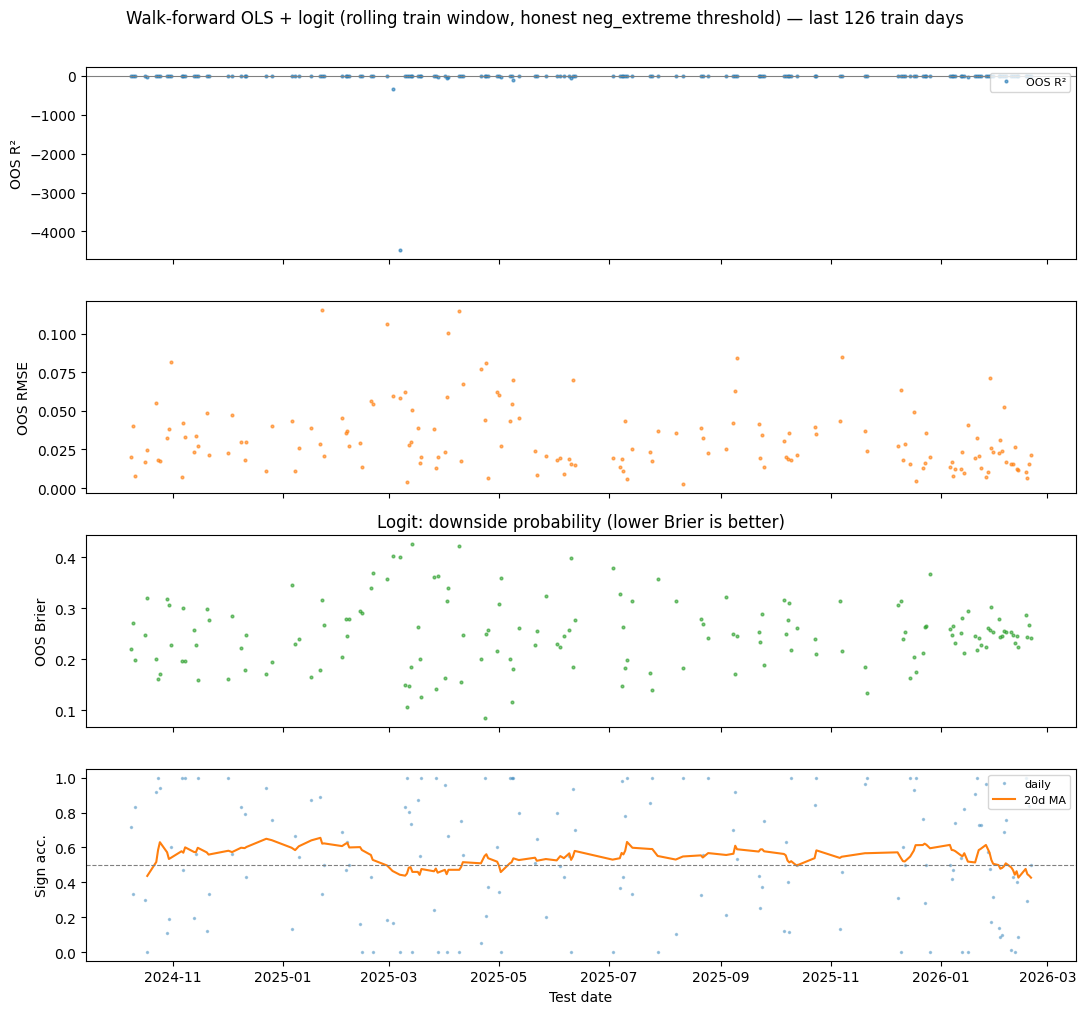

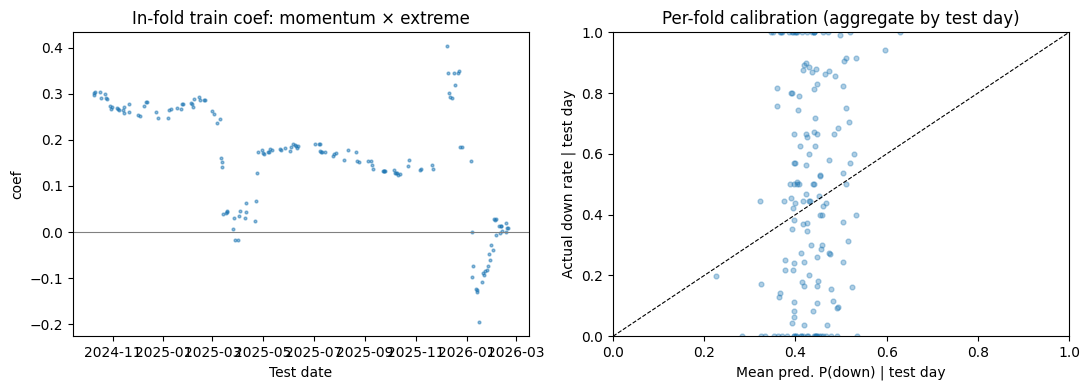

In [ ]:
if wf_results.empty:
    print("No walk-forward rows; relax MIN_TRAIN_ROWS or ROLLING_TRAIN_DAYS.")
else:
    fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

    axes[0].plot(wf_results["test_date"], wf_results["ols_r2_oos"], ".", alpha=0.6, ms=4, label="OOS R²")
    axes[0].axhline(0, color="gray", lw=0.8)
    axes[0].set_ylabel("OOS R²")
    axes[0].legend(loc="upper right", fontsize=8)

    axes[1].plot(wf_results["test_date"], wf_results["ols_rmse_oos"], ".", alpha=0.6, ms=4, color="C1")
    axes[1].set_ylabel("OOS RMSE")

    axes[2].plot(
        wf_results["test_date"],
        wf_results["logit_brier_oos"],
        ".",
        alpha=0.6,
        ms=4,
        color="C2",
    )
    axes[2].set_ylabel("OOS Brier")
    axes[2].set_title("Logit: downside probability (lower Brier is better)")

    ma = wf_results["sign_accuracy"].rolling(20, min_periods=5).mean()
    axes[3].plot(wf_results["test_date"], wf_results["sign_accuracy"], ".", alpha=0.35, ms=3, label="daily")
    axes[3].plot(wf_results["test_date"], ma, "-", lw=1.5, label="20d MA")
    axes[3].axhline(0.5, color="gray", lw=0.8, linestyle="--")
    axes[3].set_ylabel("Sign acc.")
    axes[3].set_xlabel("Test date")
    axes[3].legend(loc="upper right", fontsize=8)

    plt.suptitle(
        "Walk-forward OLS + logit (rolling train window, honest neg_extreme threshold)"
        + (" — expanding train" if USE_EXPANDING_WINDOW else f" - last {ROLLING_TRAIN_DAYS} train days"),
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(wf_results["test_date"], wf_results["coef_ixn_train"], ".", alpha=0.5, ms=4)
    axes[0].axhline(0, color="gray", lw=0.8)
    axes[0].set_title("In-fold train coef: momentum * extreme")
    axes[0].set_ylabel("coef")
    axes[0].set_xlabel("Test date")

    sub = wf_results.dropna(subset=["mean_pred_p_down", "actual_down_rate"])
    if len(sub) > 5:
        axes[1].scatter(sub["mean_pred_p_down"], sub["actual_down_rate"], alpha=0.35, s=12)
        lims = 0, 1
        axes[1].plot(lims, lims, "k--", lw=0.8)
        axes[1].set_xlim(lims)
        axes[1].set_ylim(lims)
        axes[1].set_xlabel("Mean pred. P(down) | test day")
        axes[1].set_ylabel("Actual down rate | test day")
        axes[1].set_title("Per-fold calibration (aggregate by test day)")
    else:
        axes[1].text(0.5, 0.5, "Insufficient logit preds", ha="center")
    plt.tight_layout()
    plt.show()


## Findings

This notebook extends **`04-hyp_neg_sent_momentum.ipynb`** with **time-aware walk-forward validation** (rolling training window) and an **honest** `neg_extreme` cutoff: each fold uses the sentiment quantile from **training rows only** (same numeric threshold applied to the test day—no peeking).

Specification (unchanged from 04):

> `forward_return_1d ~ momentum_1d + neg_extreme + (momentum_1d * neg_extreme)`


### Results

1. **Inference on the full pooled sample (Sections 1–3)**  
   The interaction shows up **in-sample** with **HC1** robust standard errors (see `docs/metrics.md`). With **one-way clustering by calendar `price_date`**, the interaction **p-value** is about **0.07** in the saved run (**borderline** at the usual 5% bar). With clustering by **`ticker`**, it looks much stronger. **Which error structure you assume** changes how “significant” the interaction appears.

2. **Downside probability (in-sample logit, Section 3)**  
   **Average marginal effects** still suggest the **interaction** matters for the chance of a **negative next-day return** when the whole sample is used. That speaks to **sign / probability in-sample**; it still does **not** mean we can reliably forecast **return size** out of sample.

3. **Walk-forward OLS (Section 4, honest threshold)**  
   **Out-of-sample R²** for next-day **return** is mostly **negative** when you look at the **median** across walk-forward folds (e.g. **median near −0.9** in the `wf_results.describe()` table from a full run). 
   - The **mean** OOS R² is **misleading** here because a few folds with **tiny `n_test`** blow up. 
   - **Sign accuracy** is only a little above **50%** on average. **Do not** mix up logit **pseudo R²** (~0.008 in-sample) with **walk-forward OLS** out-of-sample R².

4. **Takeaway**  
   After **date clustering** and especially under **honest walk-forward**, a **linear** model of **next-day return magnitude** is **not** a dependable **forecasting** device in this setup. 
   > Treat sentiment mainly as a **modifier** only in an **exploratory** sense unless OOS metrics improve (more test rows per day, other horizons, regime splits).

### Conclusion

> **Momentum** is still the dominant **linear** piece **in-sample** on **negative** headlines, and **sentiment shows up mostly through the interaction**. The **walk-forward** exercise does **not** support calling sentiment a **reliable, tradable modifier** of **return forecasts**; **in-sample logit** results and **out-of-sample return** R² answer **different questions** and should be kept **separate** in write-ups.

### Next steps

- For OOS R², prefer **median** and **spread** (IQR), or the **share of folds with R² below zero**, instead of the **mean** OOS R² when **test-day counts** are small.
- **Regime splits** (early / mid / late sample) and **minimum test-day coverage** rules to reduce unstable folds.
- Optional: **two-way** clustering or block bootstrap if both **date** and **ticker** dependence matter.